In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.utils import run_classification_experiment, train_and_plot_regression, train_and_plot_classification, plot_results_DL, train_on_custom_folds
from utils.utils import DataLoader

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]
data_loader = DataLoader(base_path, exp_list=all)

# Load Labels and Features
labels = data_loader.get_labels()

features = np.column_stack([
    data_loader.get_max_values(),
    data_loader.get_feature("MeanMagnitudes"),
    data_loader.get_feature("StdMagnitudes"),
    data_loader.get_feature("MedianMagnitudes"),
    data_loader.get_feature("SkewnessMagnitudes"),
    data_loader.get_feature("KurtosisMagnitudes"),
    data_loader.get_feature("EntropyMagnitudes"),
    data_loader.get_feature("SpectralEntropyMagnitudes"),
    data_loader.get_feature("PeakCountMagnitudes"),
    data_loader.get_feature("ImpulseFactorMagnitudes"),
    data_loader.get_feature("CrestFactorMagnitudes"),
    data_loader.get_feature("ClearanceFactorMagnitudes")
])



🔄 Loading data for NewExp1...
🔄 Loading data for NewExp2...
🔄 Loading data for NewExp3...
🔄 Loading data for NewExp4...
🔄 Loading data for NewExp5...
🔄 Loading data for NewExp6...
🔄 Loading data for NewExp7...
🔄 Loading data for NewExp8...
🔄 Loading data for NewExp9...
🔄 Loading data for NewExp10...
🔄 Loading data for NewExp11...
🔄 Loading data for NewExp12...
🔄 Loading data for NewExp13...
🔄 Loading data for NewExp14...
🔄 Loading data for NewExp15...
🔄 Loading data for NewExp16...
🔄 Loading data for NewExp17...
🔄 Loading data for NewExp18...
🔄 Loading data for NewExp19...
🔄 Loading data for NewExp20...
🔄 Loading data for NewExp21...
🔄 Loading data for NewExp22...
🔄 Loading data for NewExp23...
🔄 Loading data for NewExp24...
🔄 Loading data for NewExp25...
🔄 Loading data for NewExp26...
🔄 Loading data for NewExp27...
🔄 Loading data for NewExp28...
🔄 Loading data for NewExp29...
🔄 Loading data for NewExp30...
🔄 Loading data for NewExp31...
🔄 Loading data for NewExp32...
🔄 Loading data fo

📉 MSE Fold 1: 8.21
📉 MSE Fold 2: 7.44
📉 MSE Fold 3: 18.00
📉 MSE Fold 4: 9.65
📉 MSE Fold 5: 10.26
📉 MSE Fold 6: 8.16
📉 MSE Fold 7: 6.22
📉 MSE Fold 8: 7.96

🔢 MSE moyenne sur tous les folds: 9.49


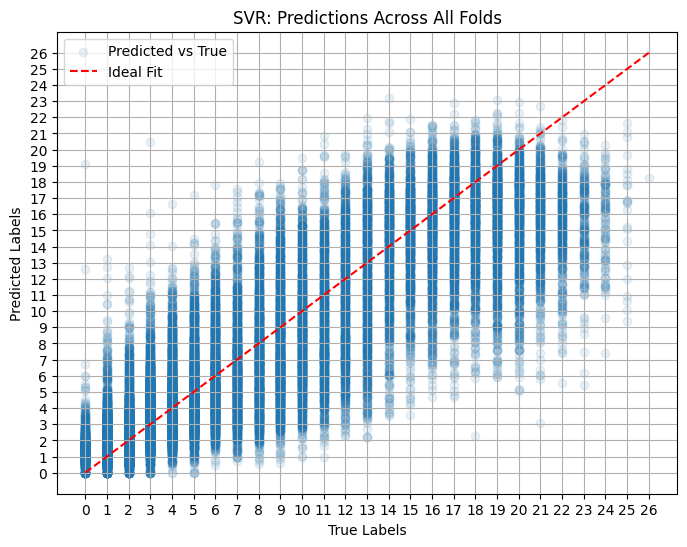

In [2]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# 📌 Charger `features` et `labels`
model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.5)

features = ["MeanMagnitudes", "StdMagnitudes", "MedianMagnitudes", "SkewnessMagnitudes", 
            "KurtosisMagnitudes", "EntropyMagnitudes", "SpectralEntropyMagnitudes", 
            "PeakCountMagnitudes", "ImpulseFactorMagnitudes", "CrestFactorMagnitudes", 
            "ClearanceFactorMagnitudes"]

all_y_pred, all_y_test = train_on_custom_folds(model, data_loader, features, "folds_config.yaml")

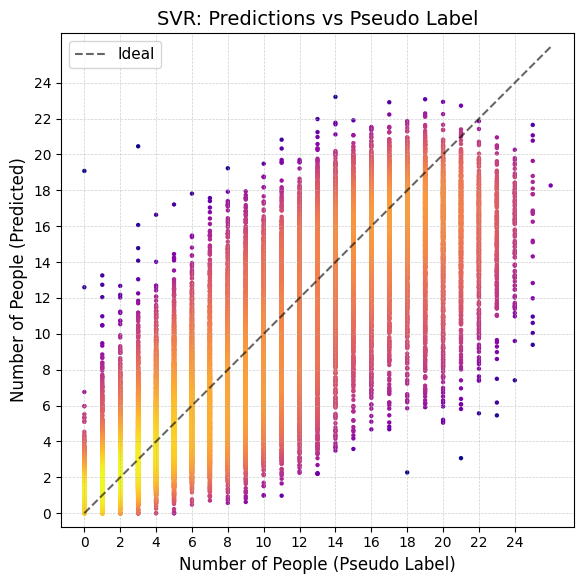

In [10]:
from scipy.stats import gaussian_kde
from matplotlib.colors import LogNorm

# Transform to numpy arrays
all_y_pred = np.array(all_y_pred)
all_y_test = np.array(all_y_test)

# Calcul de la densité
xy = np.vstack([all_y_test, all_y_pred])
z = gaussian_kde(xy)(xy)

# Tri pour rendre visibles les points denses
idx = z.argsort()
x, y, z = all_y_test[idx], all_y_pred[idx], z[idx]

# Style du plot
plt.rcParams.update({
    #'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Plot
plt.figure(figsize=(6, 6))
sc = plt.scatter(x, y, c=z, cmap='plasma', norm=LogNorm(), s=10, edgecolors='none')

# Diagonale parfaite
plt.plot([0, 26], [0, 26], color='black', linestyle='--', alpha = 0.6, linewidth=1.5, label='Ideal')

# Axes
ax = plt.gca()
ax.set_xticks(np.arange(0, 26, 2))
ax.set_yticks(np.arange(0, 26, 2))
ax.set_xlim(0, 26)
ax.set_ylim(0, 26)

# Labels, titre, légende
plt.xlabel('Number of People (Pseudo Label)', fontsize=12)
plt.ylabel('Number of People (Predicted)', fontsize=12)
plt.title('SVR: Predictions vs Pseudo Label', fontsize=14)

#plt.colorbar(sc, label='Log-scaled Point Density')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.axis('equal')
plt.tight_layout()

# Sauvegarde
plt.savefig("pred_vs_gt_scatter_log_density.pdf")
#plt.show()

📉 MSE Fold 1: 13.12
📉 MSE Fold 2: 14.95
📉 MSE Fold 3: 30.68
📉 MSE Fold 4: 21.07
📉 MSE Fold 5: 24.58
📉 MSE Fold 6: 13.30
📉 MSE Fold 7: 11.32
📉 MSE Fold 8: 15.06


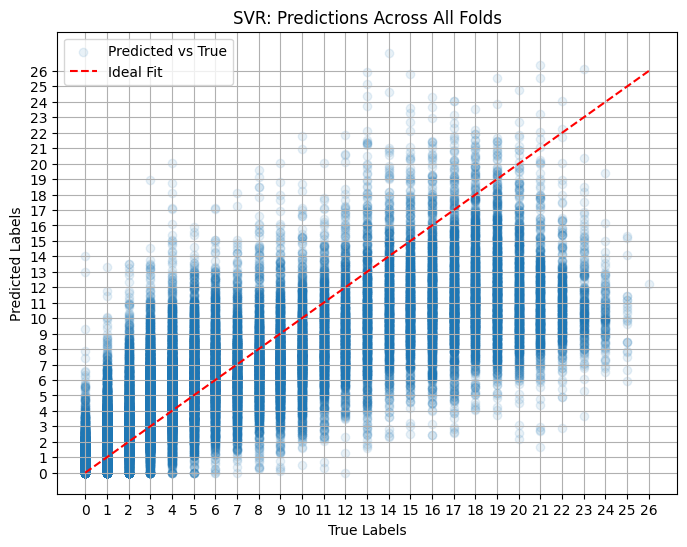


🔢 MSE moyenne sur tous les folds: 18.01
Tested C=1, epsilon=0.01, gamma=0.001 → Mean MSE: 18.0113
📉 MSE Fold 1: 9.66
📉 MSE Fold 2: 9.86
📉 MSE Fold 3: 21.36
📉 MSE Fold 4: 13.60
📉 MSE Fold 5: 15.95
📉 MSE Fold 6: 9.39
📉 MSE Fold 7: 8.04
📉 MSE Fold 8: 10.79


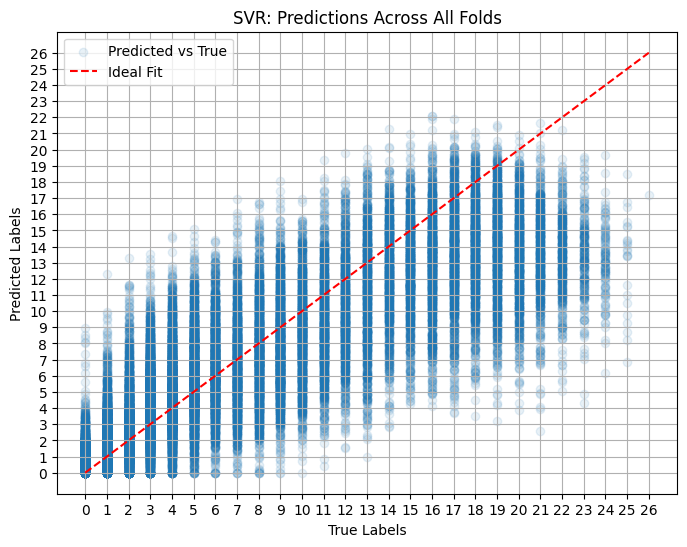


🔢 MSE moyenne sur tous les folds: 12.33
Tested C=1, epsilon=0.01, gamma=0.01 → Mean MSE: 12.3292
📉 MSE Fold 1: 8.95
📉 MSE Fold 2: 8.77
📉 MSE Fold 3: 17.92
📉 MSE Fold 4: 11.15
📉 MSE Fold 5: 12.04
📉 MSE Fold 6: 8.50
📉 MSE Fold 7: 7.19
📉 MSE Fold 8: 9.43


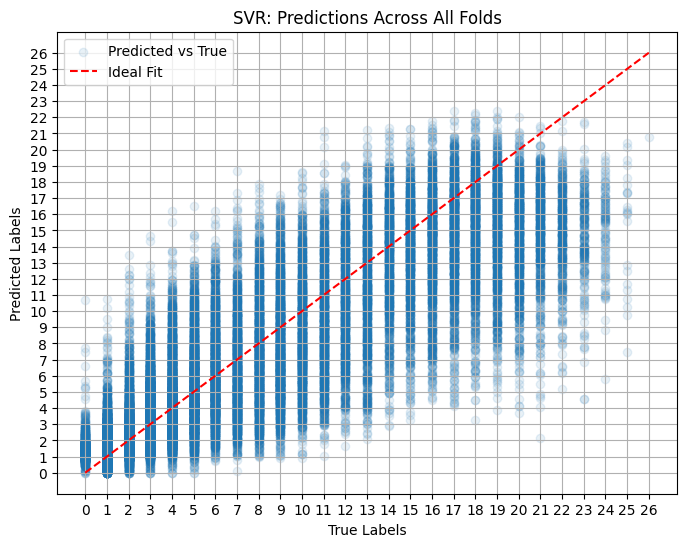


🔢 MSE moyenne sur tous les folds: 10.49
Tested C=1, epsilon=0.01, gamma=0.1 → Mean MSE: 10.4937
📉 MSE Fold 1: 9.43
📉 MSE Fold 2: 10.49
📉 MSE Fold 3: 17.88
📉 MSE Fold 4: 12.05
📉 MSE Fold 5: 12.47
📉 MSE Fold 6: 8.89
📉 MSE Fold 7: 7.76
📉 MSE Fold 8: 11.34


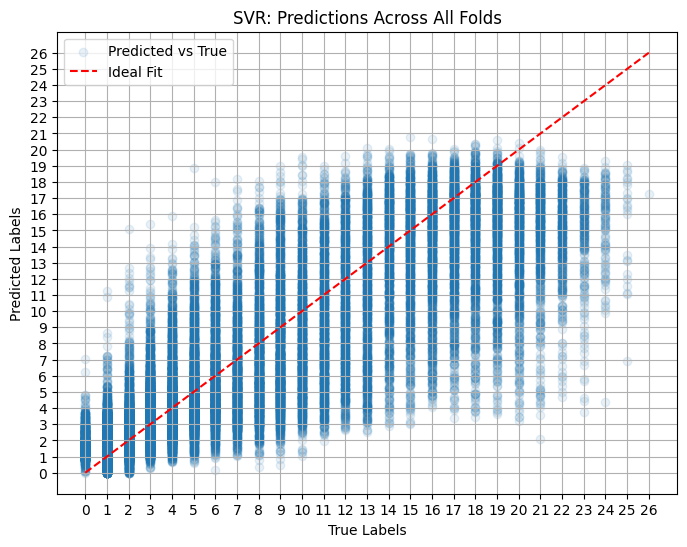


🔢 MSE moyenne sur tous les folds: 11.29
Tested C=1, epsilon=0.01, gamma=1 → Mean MSE: 11.2897
📉 MSE Fold 1: 13.10
📉 MSE Fold 2: 14.94
📉 MSE Fold 3: 30.68
📉 MSE Fold 4: 21.07
📉 MSE Fold 5: 24.57
📉 MSE Fold 6: 13.29
📉 MSE Fold 7: 11.32
📉 MSE Fold 8: 15.07


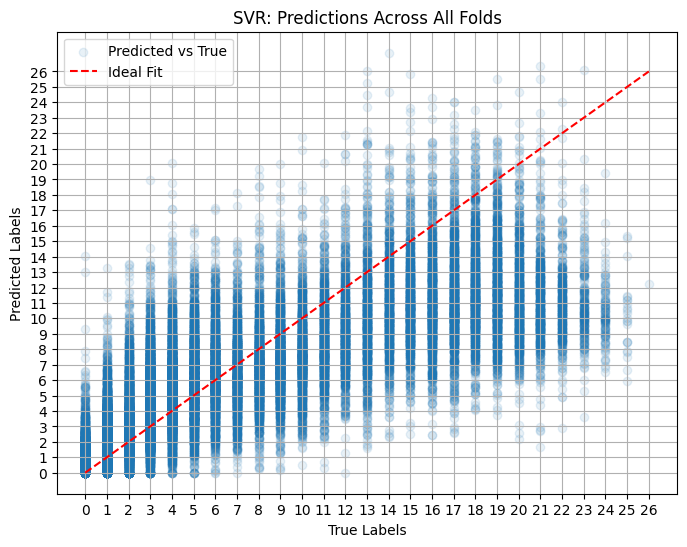


🔢 MSE moyenne sur tous les folds: 18.01
Tested C=1, epsilon=0.1, gamma=0.001 → Mean MSE: 18.0064
📉 MSE Fold 1: 9.65
📉 MSE Fold 2: 9.88
📉 MSE Fold 3: 21.36
📉 MSE Fold 4: 13.56
📉 MSE Fold 5: 15.94
📉 MSE Fold 6: 9.39
📉 MSE Fold 7: 8.04
📉 MSE Fold 8: 10.80


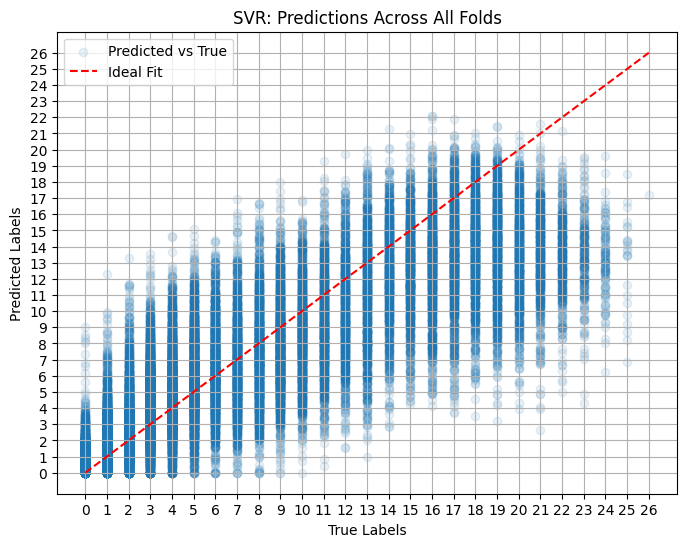


🔢 MSE moyenne sur tous les folds: 12.33
Tested C=1, epsilon=0.1, gamma=0.01 → Mean MSE: 12.3276
📉 MSE Fold 1: 8.94
📉 MSE Fold 2: 8.80
📉 MSE Fold 3: 17.93
📉 MSE Fold 4: 11.15
📉 MSE Fold 5: 12.03
📉 MSE Fold 6: 8.50
📉 MSE Fold 7: 7.20
📉 MSE Fold 8: 9.43


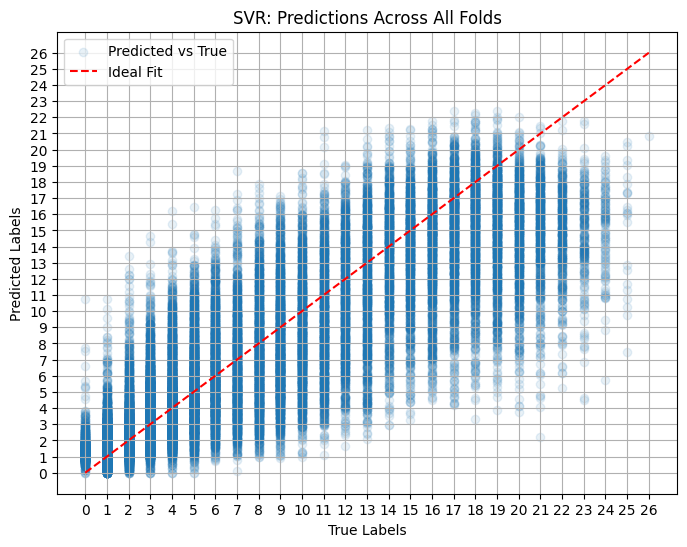


🔢 MSE moyenne sur tous les folds: 10.50
Tested C=1, epsilon=0.1, gamma=0.1 → Mean MSE: 10.4980
📉 MSE Fold 1: 9.42
📉 MSE Fold 2: 10.49
📉 MSE Fold 3: 17.90
📉 MSE Fold 4: 12.05
📉 MSE Fold 5: 12.48
📉 MSE Fold 6: 8.89
📉 MSE Fold 7: 7.76
📉 MSE Fold 8: 11.33


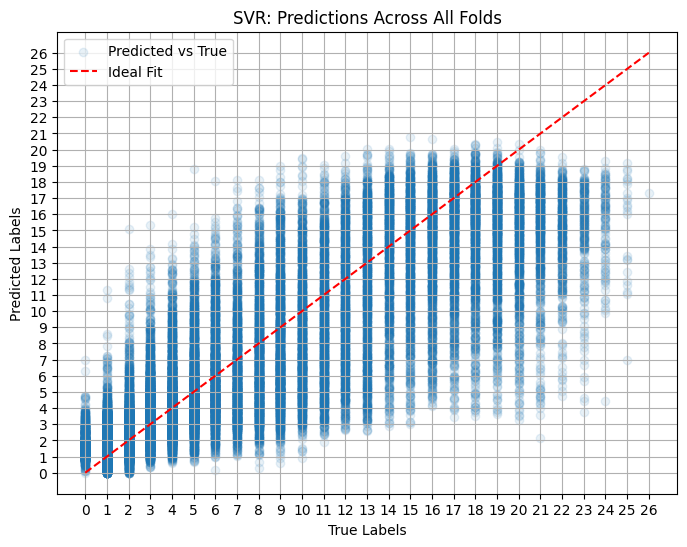


🔢 MSE moyenne sur tous les folds: 11.29
Tested C=1, epsilon=0.1, gamma=1 → Mean MSE: 11.2879
📉 MSE Fold 1: 13.05
📉 MSE Fold 2: 14.88
📉 MSE Fold 3: 30.54
📉 MSE Fold 4: 20.99
📉 MSE Fold 5: 24.46
📉 MSE Fold 6: 13.28
📉 MSE Fold 7: 11.27
📉 MSE Fold 8: 15.02


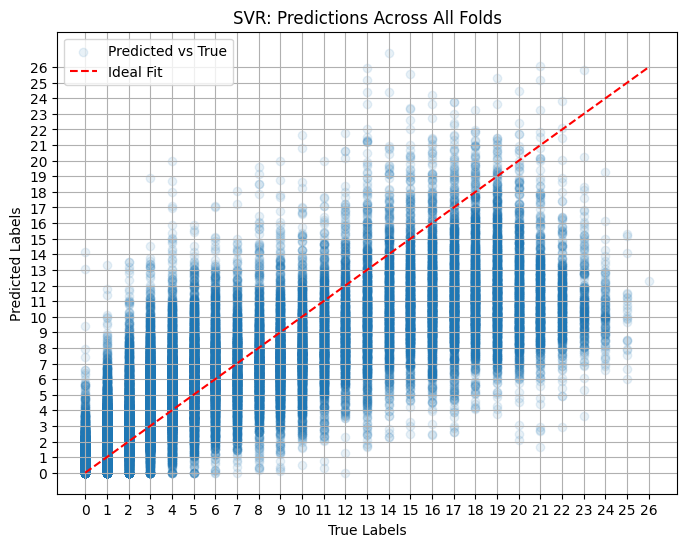


🔢 MSE moyenne sur tous les folds: 17.94
Tested C=1, epsilon=0.5, gamma=0.001 → Mean MSE: 17.9351
📉 MSE Fold 1: 9.63
📉 MSE Fold 2: 9.87
📉 MSE Fold 3: 21.30
📉 MSE Fold 4: 13.53
📉 MSE Fold 5: 15.92
📉 MSE Fold 6: 9.39
📉 MSE Fold 7: 8.02
📉 MSE Fold 8: 10.75


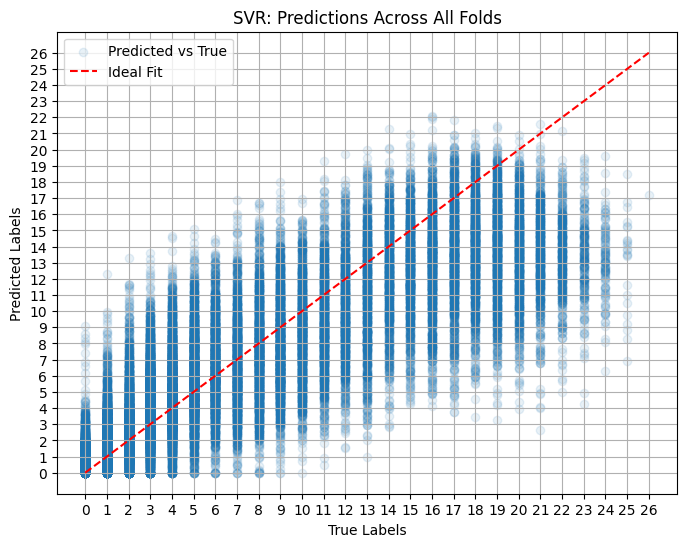


🔢 MSE moyenne sur tous les folds: 12.30
Tested C=1, epsilon=0.5, gamma=0.01 → Mean MSE: 12.3028
📉 MSE Fold 1: 8.90
📉 MSE Fold 2: 8.88
📉 MSE Fold 3: 18.00
📉 MSE Fold 4: 11.05
📉 MSE Fold 5: 12.09
📉 MSE Fold 6: 8.48
📉 MSE Fold 7: 7.23
📉 MSE Fold 8: 9.44


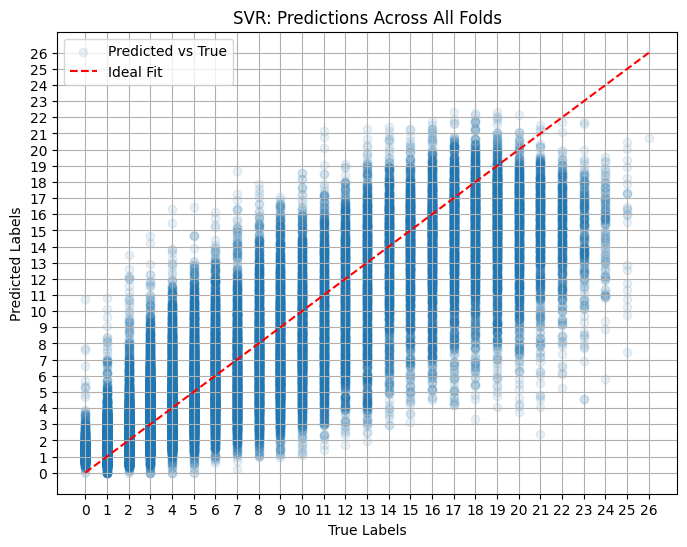


🔢 MSE moyenne sur tous les folds: 10.51
Tested C=1, epsilon=0.5, gamma=0.1 → Mean MSE: 10.5097
📉 MSE Fold 1: 9.40
📉 MSE Fold 2: 10.50
📉 MSE Fold 3: 17.89
📉 MSE Fold 4: 11.96
📉 MSE Fold 5: 12.44
📉 MSE Fold 6: 8.85
📉 MSE Fold 7: 7.70
📉 MSE Fold 8: 11.35


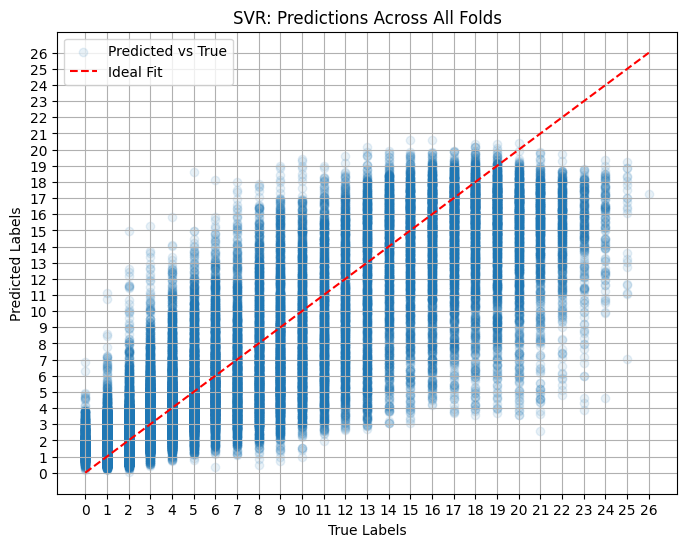


🔢 MSE moyenne sur tous les folds: 11.26
Tested C=1, epsilon=0.5, gamma=1 → Mean MSE: 11.2629
📉 MSE Fold 1: 9.81
📉 MSE Fold 2: 10.50
📉 MSE Fold 3: 22.79
📉 MSE Fold 4: 14.71
📉 MSE Fold 5: 17.39
📉 MSE Fold 6: 9.70
📉 MSE Fold 7: 8.27
📉 MSE Fold 8: 11.14


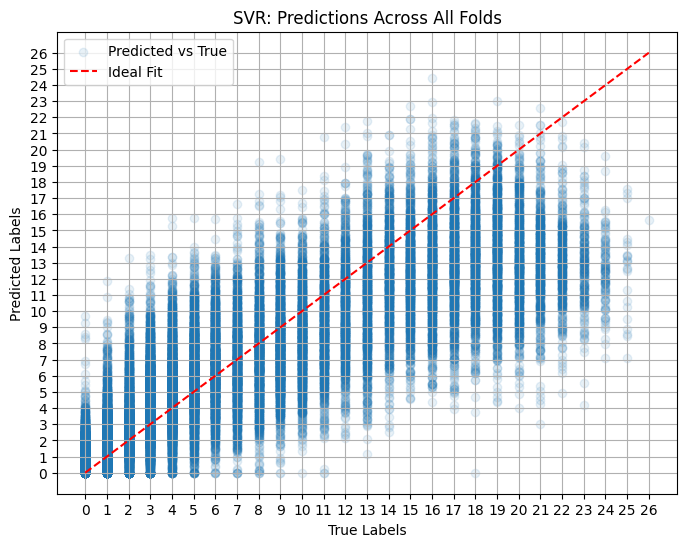


🔢 MSE moyenne sur tous les folds: 13.04
Tested C=10, epsilon=0.01, gamma=0.001 → Mean MSE: 13.0407
📉 MSE Fold 1: 8.69
📉 MSE Fold 2: 8.31
📉 MSE Fold 3: 18.89
📉 MSE Fold 4: 11.14
📉 MSE Fold 5: 12.84
📉 MSE Fold 6: 8.29
📉 MSE Fold 7: 6.91
📉 MSE Fold 8: 9.13


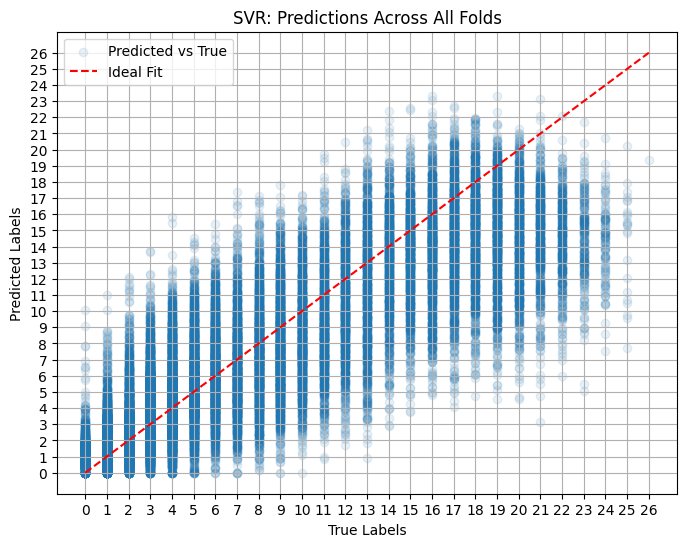


🔢 MSE moyenne sur tous les folds: 10.53
Tested C=10, epsilon=0.01, gamma=0.01 → Mean MSE: 10.5268
📉 MSE Fold 1: 8.44
📉 MSE Fold 2: 7.76
📉 MSE Fold 3: 17.64
📉 MSE Fold 4: 9.98
📉 MSE Fold 5: 10.87
📉 MSE Fold 6: 8.11
📉 MSE Fold 7: 6.43
📉 MSE Fold 8: 8.24


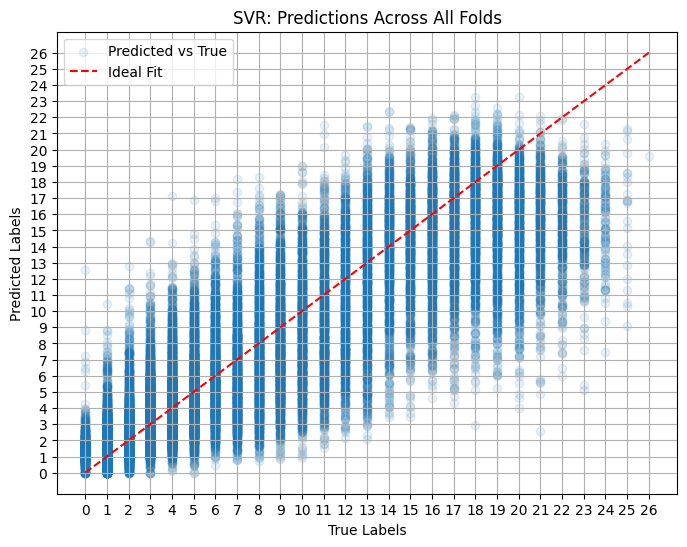


🔢 MSE moyenne sur tous les folds: 9.68
Tested C=10, epsilon=0.01, gamma=0.1 → Mean MSE: 9.6842
📉 MSE Fold 1: 9.07
📉 MSE Fold 2: 8.59
📉 MSE Fold 3: 17.72
📉 MSE Fold 4: 10.79
📉 MSE Fold 5: 11.31
📉 MSE Fold 6: 9.02
📉 MSE Fold 7: 7.29
📉 MSE Fold 8: 9.44


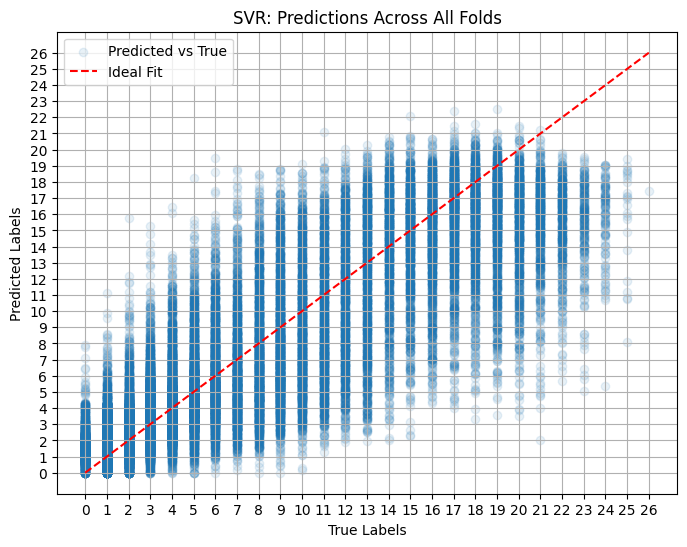


🔢 MSE moyenne sur tous les folds: 10.40
Tested C=10, epsilon=0.01, gamma=1 → Mean MSE: 10.4043
📉 MSE Fold 1: 9.82
📉 MSE Fold 2: 10.52
📉 MSE Fold 3: 22.77
📉 MSE Fold 4: 14.74
📉 MSE Fold 5: 17.40
📉 MSE Fold 6: 9.70
📉 MSE Fold 7: 8.28
📉 MSE Fold 8: 11.14


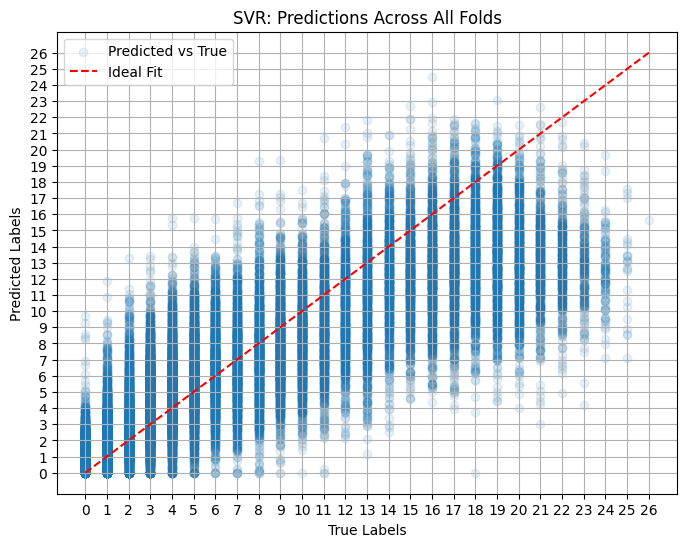


🔢 MSE moyenne sur tous les folds: 13.04
Tested C=10, epsilon=0.1, gamma=0.001 → Mean MSE: 13.0450
📉 MSE Fold 1: 8.69
📉 MSE Fold 2: 8.31
📉 MSE Fold 3: 18.90
📉 MSE Fold 4: 11.14
📉 MSE Fold 5: 12.85
📉 MSE Fold 6: 8.28
📉 MSE Fold 7: 6.91
📉 MSE Fold 8: 9.13


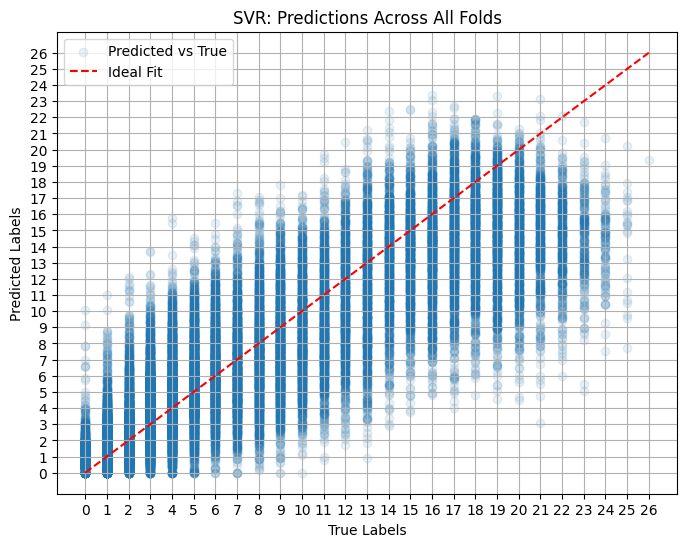


🔢 MSE moyenne sur tous les folds: 10.53
Tested C=10, epsilon=0.1, gamma=0.01 → Mean MSE: 10.5276
📉 MSE Fold 1: 8.45
📉 MSE Fold 2: 7.78
📉 MSE Fold 3: 17.65
📉 MSE Fold 4: 9.98
📉 MSE Fold 5: 10.87
📉 MSE Fold 6: 8.11
📉 MSE Fold 7: 6.45
📉 MSE Fold 8: 8.25


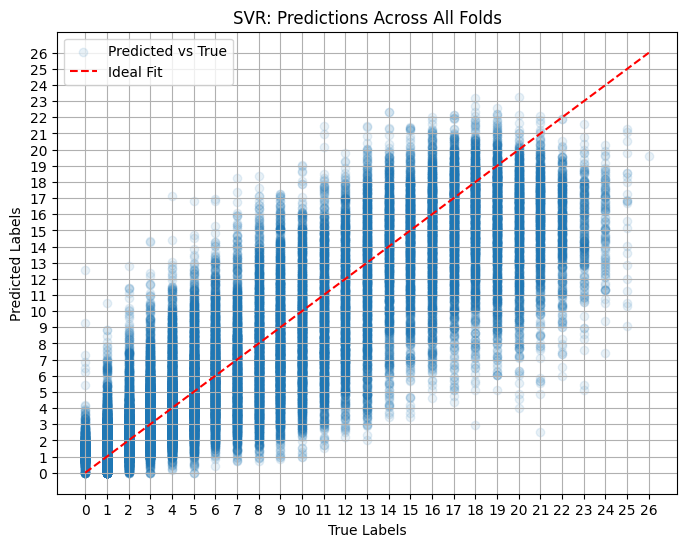


🔢 MSE moyenne sur tous les folds: 9.69
Tested C=10, epsilon=0.1, gamma=0.1 → Mean MSE: 9.6915
📉 MSE Fold 1: 9.06
📉 MSE Fold 2: 8.58
📉 MSE Fold 3: 17.72
📉 MSE Fold 4: 10.75
📉 MSE Fold 5: 11.30
📉 MSE Fold 6: 9.02
📉 MSE Fold 7: 7.27
📉 MSE Fold 8: 9.44


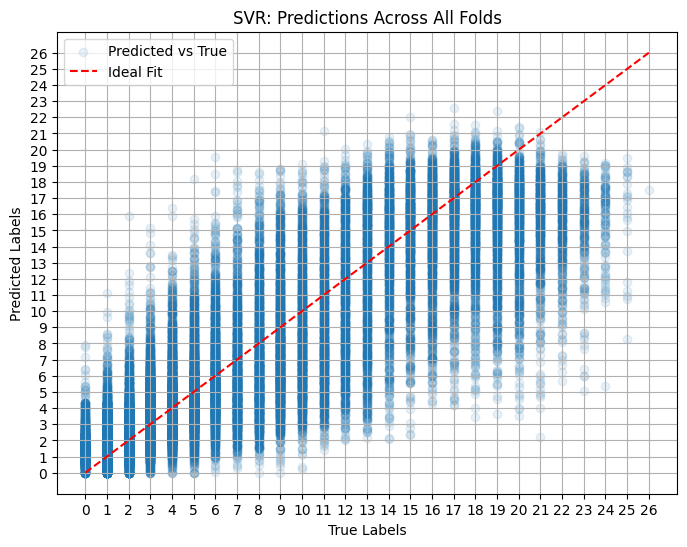


🔢 MSE moyenne sur tous les folds: 10.39
Tested C=10, epsilon=0.1, gamma=1 → Mean MSE: 10.3927
📉 MSE Fold 1: 9.80
📉 MSE Fold 2: 10.51
📉 MSE Fold 3: 22.80
📉 MSE Fold 4: 14.69
📉 MSE Fold 5: 17.40
📉 MSE Fold 6: 9.68
📉 MSE Fold 7: 8.27
📉 MSE Fold 8: 11.12


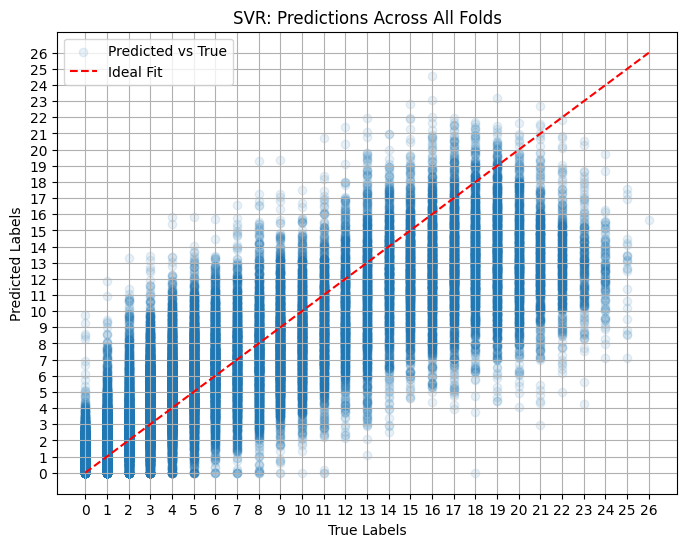


🔢 MSE moyenne sur tous les folds: 13.03
Tested C=10, epsilon=0.5, gamma=0.001 → Mean MSE: 13.0343
📉 MSE Fold 1: 8.69
📉 MSE Fold 2: 8.32
📉 MSE Fold 3: 18.84
📉 MSE Fold 4: 11.11
📉 MSE Fold 5: 12.84
📉 MSE Fold 6: 8.28
📉 MSE Fold 7: 6.91
📉 MSE Fold 8: 9.14


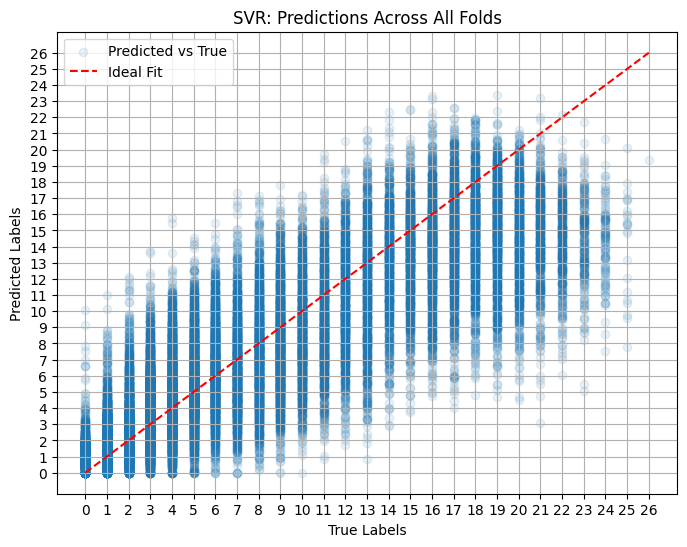


🔢 MSE moyenne sur tous les folds: 10.52
Tested C=10, epsilon=0.5, gamma=0.01 → Mean MSE: 10.5158
📉 MSE Fold 1: 8.37
📉 MSE Fold 2: 7.81
📉 MSE Fold 3: 17.63
📉 MSE Fold 4: 9.94
📉 MSE Fold 5: 10.85
📉 MSE Fold 6: 8.08
📉 MSE Fold 7: 6.47
📉 MSE Fold 8: 8.25


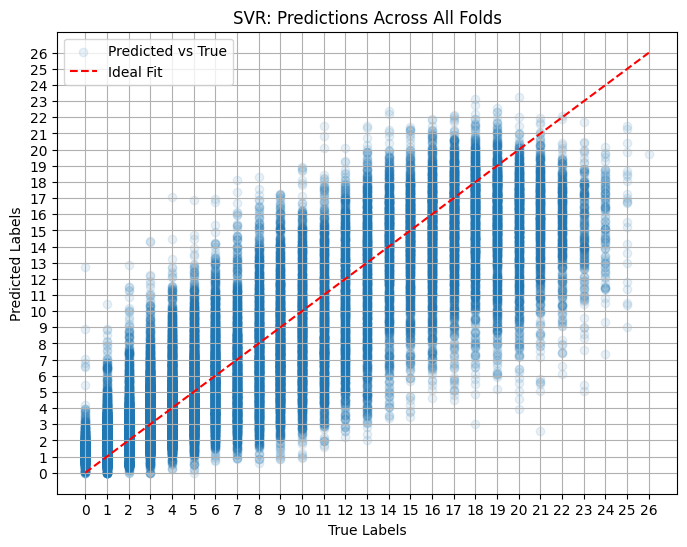


🔢 MSE moyenne sur tous les folds: 9.67
Tested C=10, epsilon=0.5, gamma=0.1 → Mean MSE: 9.6747
📉 MSE Fold 1: 8.96
📉 MSE Fold 2: 8.57
📉 MSE Fold 3: 17.69
📉 MSE Fold 4: 10.64
📉 MSE Fold 5: 11.20
📉 MSE Fold 6: 8.99
📉 MSE Fold 7: 7.16
📉 MSE Fold 8: 9.49


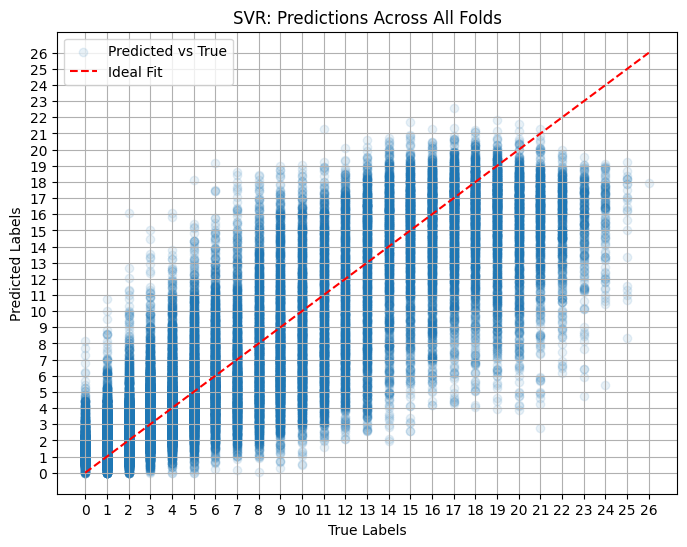


🔢 MSE moyenne sur tous les folds: 10.34
Tested C=10, epsilon=0.5, gamma=1 → Mean MSE: 10.3381
📉 MSE Fold 1: 8.88
📉 MSE Fold 2: 9.00
📉 MSE Fold 3: 19.84
📉 MSE Fold 4: 12.31
📉 MSE Fold 5: 14.38
📉 MSE Fold 6: 8.68
📉 MSE Fold 7: 7.30
📉 MSE Fold 8: 9.82


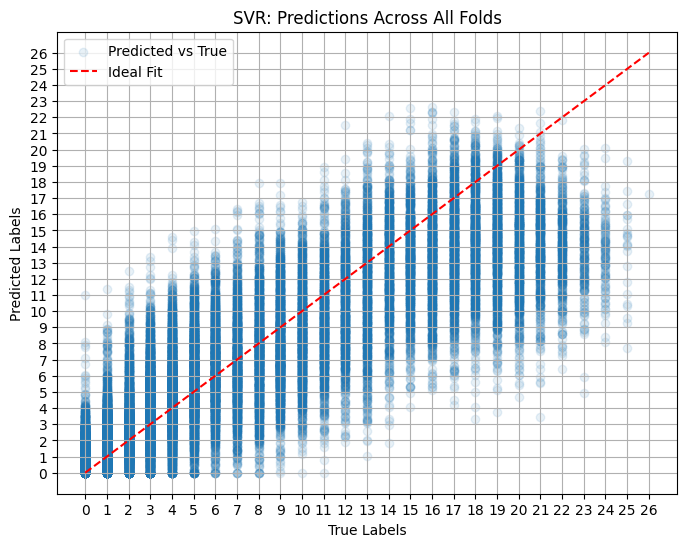


🔢 MSE moyenne sur tous les folds: 11.28
Tested C=100, epsilon=0.01, gamma=0.001 → Mean MSE: 11.2774
📉 MSE Fold 1: 8.40
📉 MSE Fold 2: 7.74
📉 MSE Fold 3: 19.16
📉 MSE Fold 4: 10.17
📉 MSE Fold 5: 11.61
📉 MSE Fold 6: 7.89
📉 MSE Fold 7: 6.39
📉 MSE Fold 8: 8.42


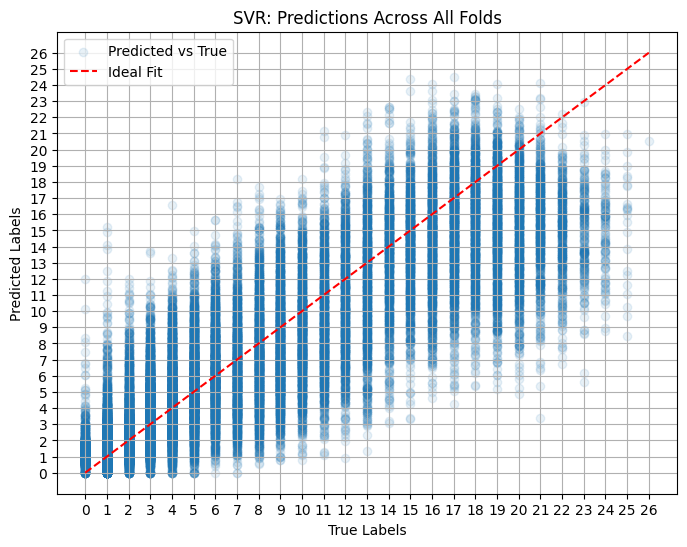


🔢 MSE moyenne sur tous les folds: 9.97
Tested C=100, epsilon=0.01, gamma=0.01 → Mean MSE: 9.9716
📉 MSE Fold 1: 8.27
📉 MSE Fold 2: 7.42
📉 MSE Fold 3: 17.87
📉 MSE Fold 4: 9.75
📉 MSE Fold 5: 10.30
📉 MSE Fold 6: 8.15
📉 MSE Fold 7: 6.23
📉 MSE Fold 8: 7.92


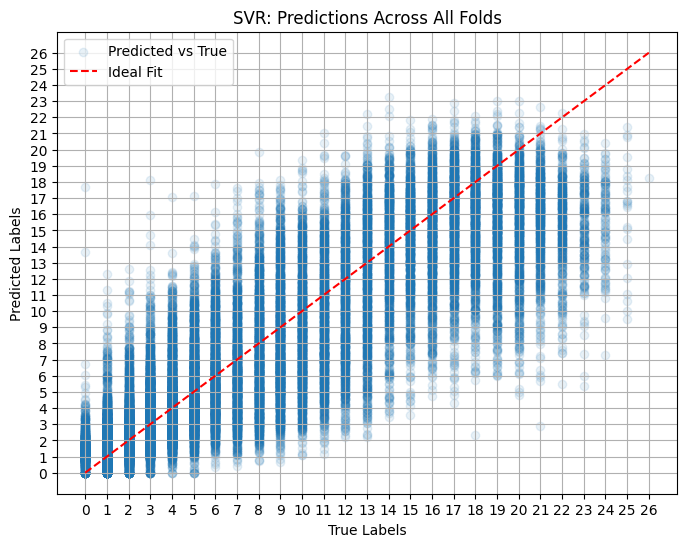


🔢 MSE moyenne sur tous les folds: 9.49
Tested C=100, epsilon=0.01, gamma=0.1 → Mean MSE: 9.4885
📉 MSE Fold 1: 9.97
📉 MSE Fold 2: 9.83
📉 MSE Fold 3: 19.43
📉 MSE Fold 4: 11.65
📉 MSE Fold 5: 11.79
📉 MSE Fold 6: 10.48
📉 MSE Fold 7: 8.13
📉 MSE Fold 8: 10.80


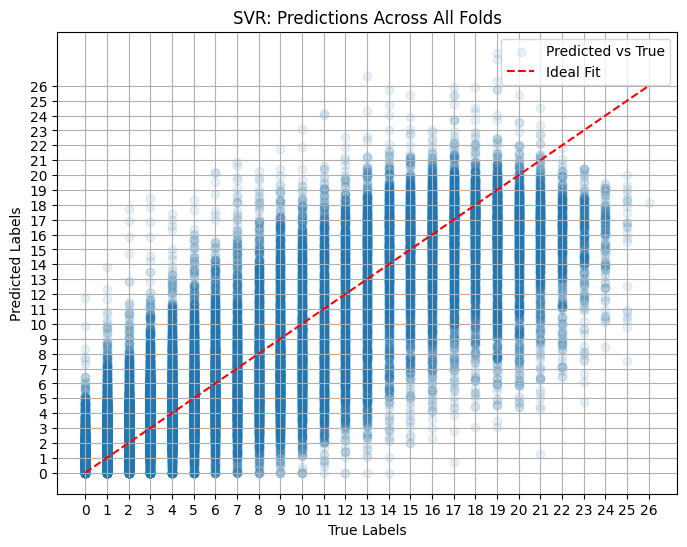


🔢 MSE moyenne sur tous les folds: 11.51
Tested C=100, epsilon=0.01, gamma=1 → Mean MSE: 11.5113
📉 MSE Fold 1: 8.88
📉 MSE Fold 2: 9.00
📉 MSE Fold 3: 19.86
📉 MSE Fold 4: 12.30
📉 MSE Fold 5: 14.37
📉 MSE Fold 6: 8.68
📉 MSE Fold 7: 7.30
📉 MSE Fold 8: 9.82


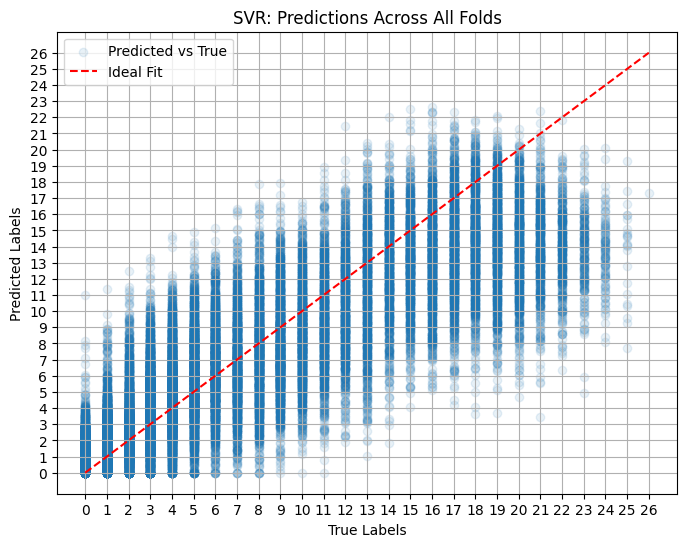


🔢 MSE moyenne sur tous les folds: 11.28
Tested C=100, epsilon=0.1, gamma=0.001 → Mean MSE: 11.2757
📉 MSE Fold 1: 8.40
📉 MSE Fold 2: 7.73
📉 MSE Fold 3: 19.12
📉 MSE Fold 4: 10.17
📉 MSE Fold 5: 11.62
📉 MSE Fold 6: 7.88
📉 MSE Fold 7: 6.39
📉 MSE Fold 8: 8.43


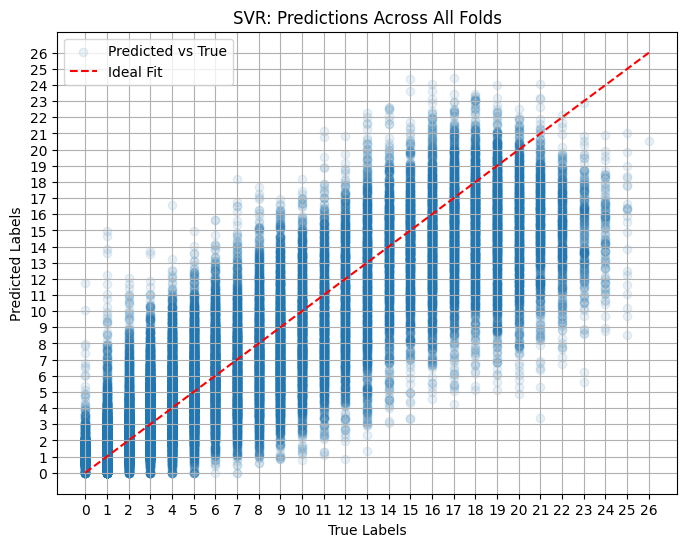


🔢 MSE moyenne sur tous les folds: 9.97
Tested C=100, epsilon=0.1, gamma=0.01 → Mean MSE: 9.9675
📉 MSE Fold 1: 8.27
📉 MSE Fold 2: 7.41
📉 MSE Fold 3: 18.01
📉 MSE Fold 4: 9.74
📉 MSE Fold 5: 10.29
📉 MSE Fold 6: 8.14
📉 MSE Fold 7: 6.23
📉 MSE Fold 8: 7.93


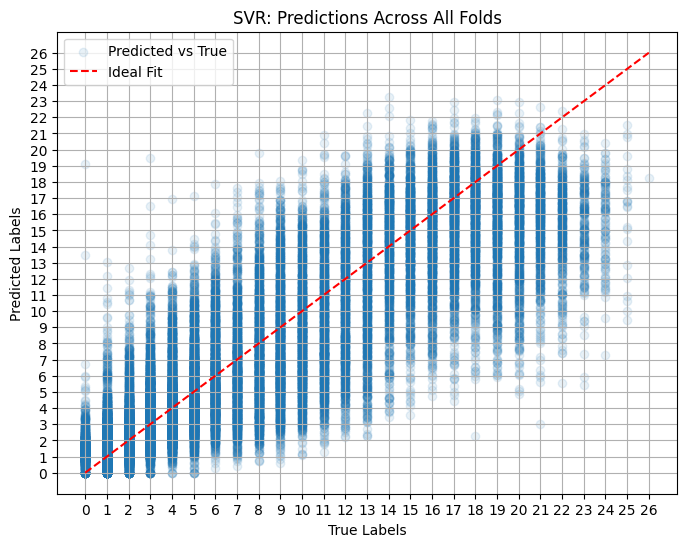


🔢 MSE moyenne sur tous les folds: 9.50
Tested C=100, epsilon=0.1, gamma=0.1 → Mean MSE: 9.5027
📉 MSE Fold 1: 9.93
📉 MSE Fold 2: 9.80
📉 MSE Fold 3: 19.36
📉 MSE Fold 4: 11.61
📉 MSE Fold 5: 11.75
📉 MSE Fold 6: 10.44
📉 MSE Fold 7: 8.09
📉 MSE Fold 8: 10.76


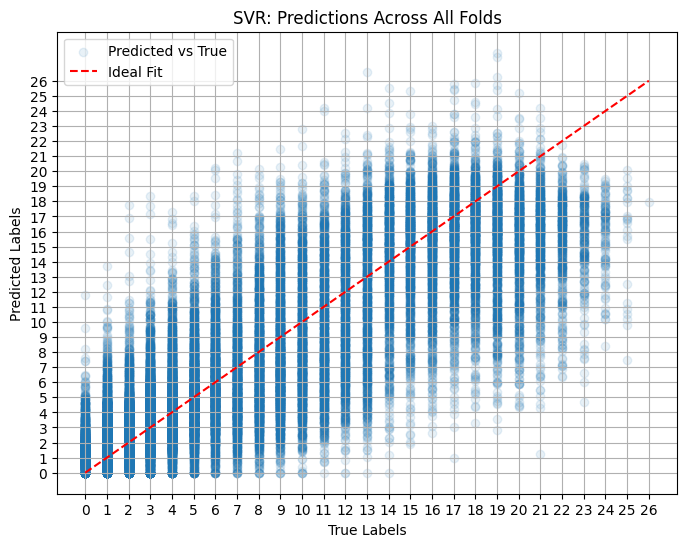


🔢 MSE moyenne sur tous les folds: 11.47
Tested C=100, epsilon=0.1, gamma=1 → Mean MSE: 11.4658
📉 MSE Fold 1: 8.86
📉 MSE Fold 2: 8.99
📉 MSE Fold 3: 19.80
📉 MSE Fold 4: 12.25


In [ ]:
from sklearn.svm import SVR
import itertools

features = ["MeanMagnitudes", "StdMagnitudes", "MedianMagnitudes", "SkewnessMagnitudes", 
            "KurtosisMagnitudes", "EntropyMagnitudes", "SpectralEntropyMagnitudes", 
            "PeakCountMagnitudes", "ImpulseFactorMagnitudes", "CrestFactorMagnitudes", 
            "ClearanceFactorMagnitudes"]

# Grille d'hyperparamètres
C_values = [1, 10, 100, 1000]
epsilon_values = [0.01, 0.1, 0.5]
gamma_values = [1e-3, 1e-2, 1e-1, 1]

# Pour stocker les résultats
results = []

# Grid search manuel
for C, epsilon, gamma in itertools.product(C_values, epsilon_values, gamma_values):
    model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
    mean_mse = train_on_custom_folds(model, data_loader, features, "folds_config.yaml")
    results.append(((C, epsilon, gamma), mean_mse))
    print(f"Tested C={C}, epsilon={epsilon}, gamma={gamma} → Mean MSE: {mean_mse:.4f}")

# Sélection du meilleur modèle
best_params, best_mse = min(results, key=lambda x: x[1])
print(f"\nBest parameters: C={best_params[0]}, epsilon={best_params[1]}, gamma={best_params[2]}")
print(f"Best mean MSE: {best_mse:.4f}")

🔹 Evaluating with N = 2 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...
🔹 Evaluating with N = 3 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...
🔹 Evaluating with N = 4 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...
🔹 Evaluating with N = 5 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...
🔹 Evaluating with N = 6 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...


/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


🔹 Evaluating with N = 7 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...
🔹 Evaluating with N = 8 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...
🔹 Evaluating with N = 9 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...
🔹 Evaluating with N = 10 classes
   ➤ Training Random Forest...
   ➤ Training SVM...
   ➤ Training MLP...


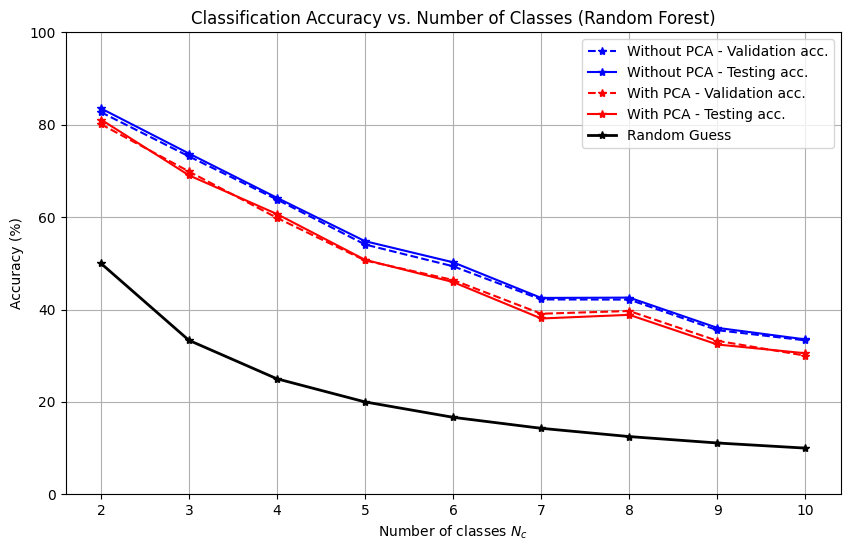

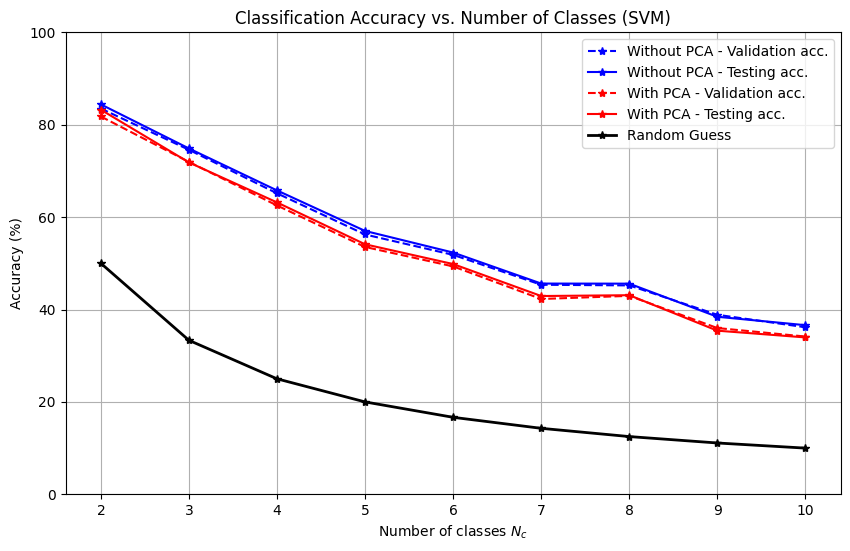

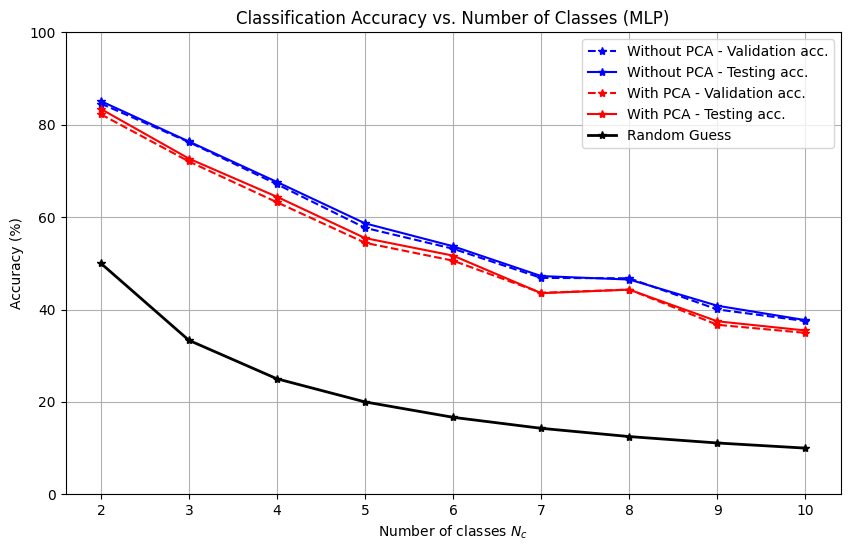

In [2]:
all_results = run_classification_experiment(features, labels, n_components_pca=6, n_classes_range=(2, 10))

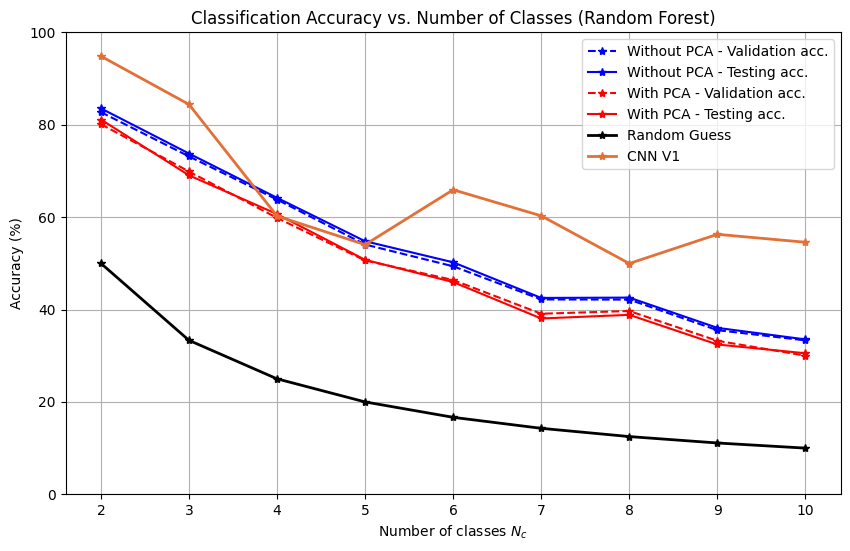

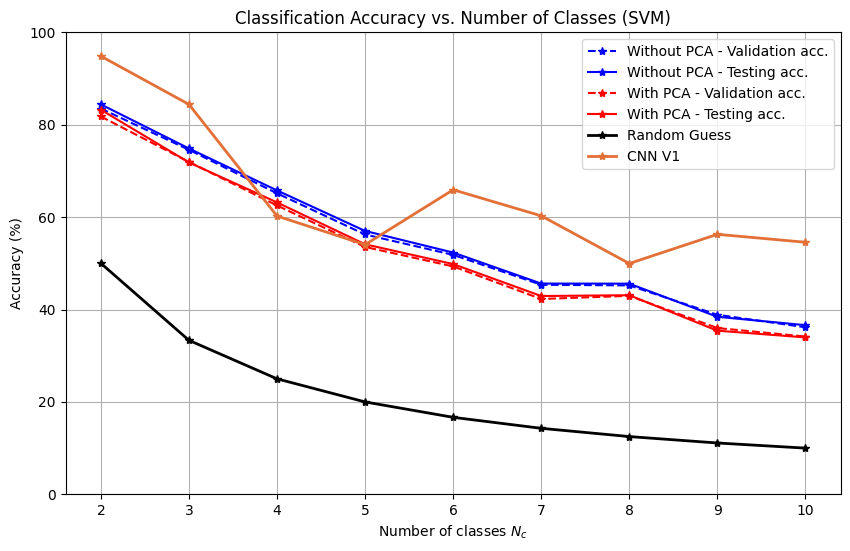

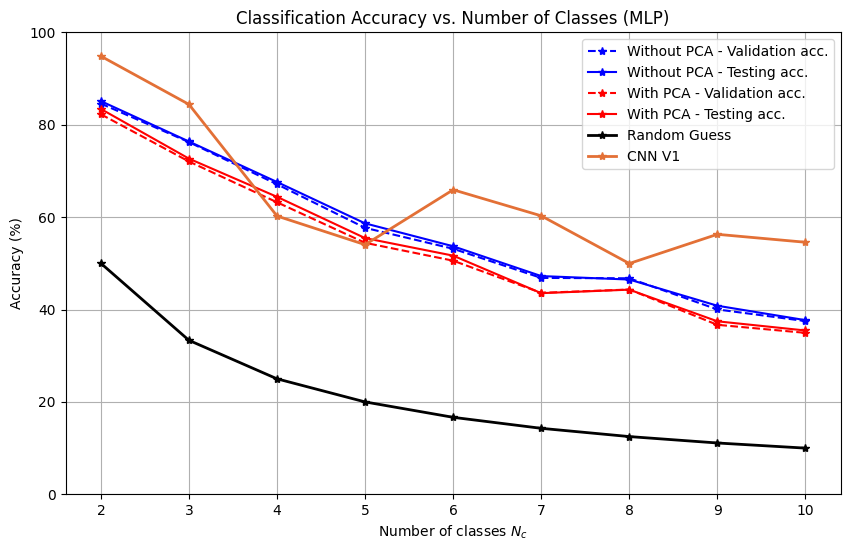

In [2]:
all_results_saved = {'Random Forest': {'N': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'Without PCA - Validation acc.': [82.72, 73.15, 63.800000000000004, 54.06999999999999, 49.36, 42.18, 42.15, 35.53, 33.32], 'Without PCA - Testing acc.': [83.54, 73.77, 64.18, 54.790000000000006, 50.22, 42.51, 42.58, 36.03, 33.53], 'With PCA - Validation acc.': [80.12, 69.88, 59.830000000000005, 50.62, 46.39, 39.09, 39.68, 33.23, 30.009999999999998], 'With PCA - Testing acc.': [81.13, 69.05, 60.660000000000004, 50.760000000000005, 45.94, 38.06, 38.85, 32.43, 30.53], 'Random Guess': [50.0, 33.33333333333333, 25.0, 20.0, 16.666666666666664, 14.285714285714285, 12.5, 11.11111111111111, 10.0]}, 'SVM': {'N': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'Without PCA - Validation acc.': [83.5, 74.57000000000001, 65.14999999999999, 56.24, 51.83, 45.36, 45.22, 38.86, 36.16], 'Without PCA - Testing acc.': [84.39999999999999, 74.86, 65.78, 57.010000000000005, 52.33, 45.62, 45.6, 38.43, 36.61], 'With PCA - Validation acc.': [81.78, 71.95, 62.519999999999996, 53.54, 49.33, 42.28, 42.96, 35.99, 34.150000000000006], 'With PCA - Testing acc.': [83.24000000000001, 71.84, 63.18, 54.120000000000005, 49.84, 42.92, 43.1, 35.42, 33.96], 'Random Guess': [50.0, 33.33333333333333, 25.0, 20.0, 16.666666666666664, 14.285714285714285, 12.5, 11.11111111111111, 10.0]}, 'MLP': {'N': [2, 3, 4, 5, 6, 7, 8, 9, 10], 'Without PCA - Validation acc.': [84.57000000000001, 76.24, 67.11, 57.68, 53.15, 46.839999999999996, 46.760000000000005, 40.02, 37.5], 'Without PCA - Testing acc.': [85.11, 76.37, 67.60000000000001, 58.650000000000006, 53.690000000000005, 47.24, 46.489999999999995, 40.82, 37.7], 'With PCA - Validation acc.': [82.26, 72.04, 63.21, 54.44, 50.57000000000001, 43.61, 44.330000000000005, 36.69, 34.949999999999996], 'With PCA - Testing acc.': [83.41, 72.66, 64.39, 55.46, 51.66, 43.54, 44.3, 37.45, 35.46], 'Random Guess': [50.0, 33.33333333333333, 25.0, 20.0, 16.666666666666664, 14.285714285714285, 12.5, 11.11111111111111, 10.0]}}
CNN_v1 = np.array([0.9484, 0.844, 0.6024, 0.5404, 0.6592, 0.6028, 0.4996, 0.5628, 0.5456]) * 100
plot_results_DL(all_results_saved, CNN_v1)


✅ Model: SVR
📉 Mean Squared Error (MSE): 9.79
📈 R² Score: 0.74


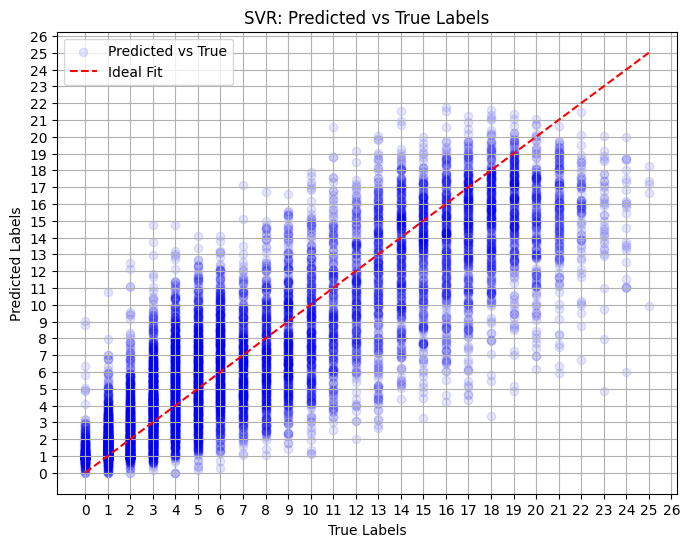

✅ Model: MLPRegressor
📉 Mean Squared Error (MSE): 8.19
📈 R² Score: 0.78


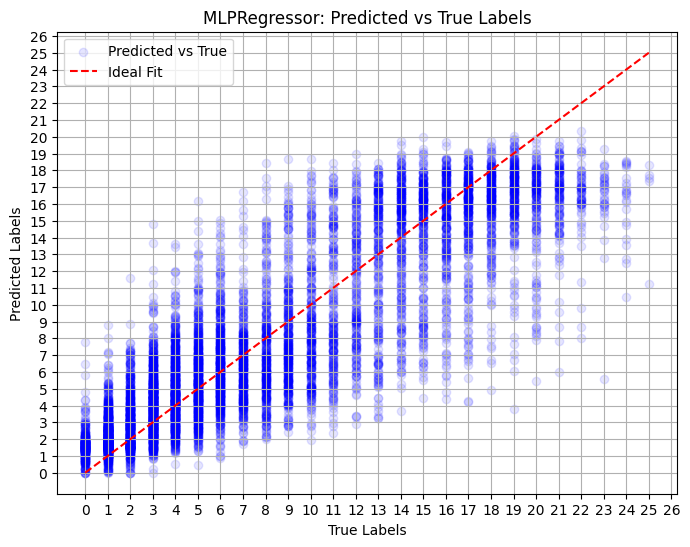

✅ Model: SVC
📈 Accuracy: 22.50%


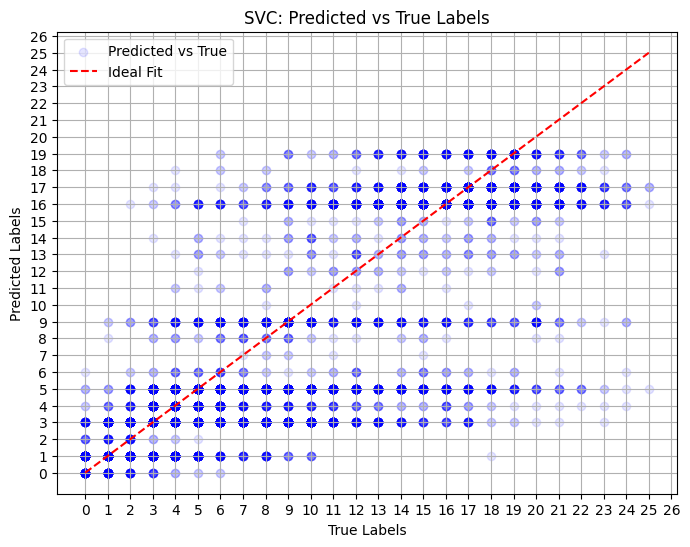

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
# Définir l'espace des hyperparamètres
param_grid = {
    'C': [1, 10, 100, 1000],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': [1e-3, 1e-2, 1e-1, 1]
}

# Initialiser le modèle de base
svr = SVR(kernel='rbf')

# Créer le GridSearch avec validation croisée (par défaut 5-fold)
grid_search = GridSearchCV(estimator=svr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Appliquer la recherche sur les données
grid_search.fit(features, labels)

# Extraire le meilleur modèle trouvé
best_model = grid_search.best_estimator_

# Afficher les meilleurs hyperparamètres
print("Best parameters found:", grid_search.best_params_)

# Réentraîner et évaluer avec le meilleur modèle (fonction fournie)
_, _ = train_and_plot_regression(best_model, features, labels)



✅ Model: LinearRegression
📉 Mean Squared Error (MSE): 10.72
📈 R² Score: 0.71
🔹 Evaluating Regression Accuracy for N = 2
🔹 Evaluating Regression Accuracy for N = 3
🔹 Evaluating Regression Accuracy for N = 4
🔹 Evaluating Regression Accuracy for N = 5
🔹 Evaluating Regression Accuracy for N = 6
🔹 Evaluating Regression Accuracy for N = 7
🔹 Evaluating Regression Accuracy for N = 8
🔹 Evaluating Regression Accuracy for N = 9
🔹 Evaluating Regression Accuracy for N = 10


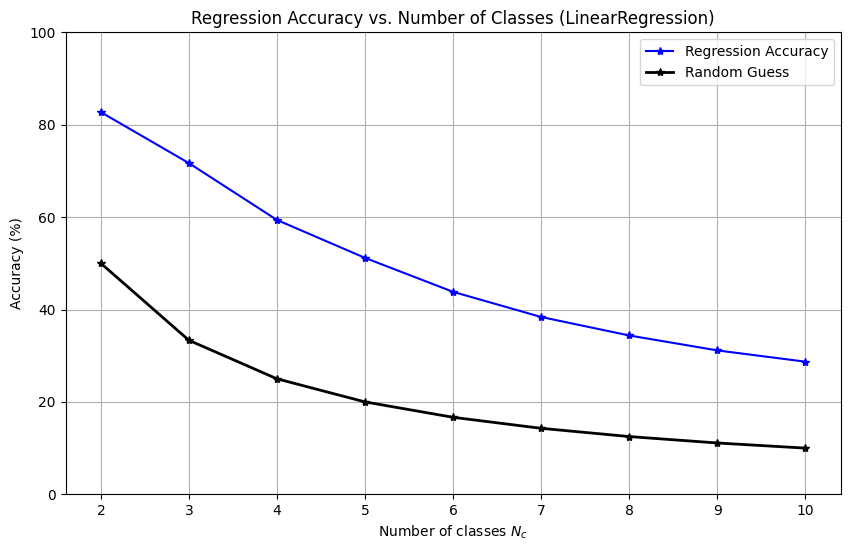

In [3]:
from utils.utils import train_and_evaluate_regression

model = LinearRegression()  # ➜ Essaie aussi Ridge(alpha=1.0), SVR(kernel="rbf"), etc.
df_results = train_and_evaluate_regression(model, features, labels)